In [26]:
import pandas as pd
import os
import numpy as np 
import json
import skimage as ski
import matplotlib.pyplot as plt
from skimage.measure import find_contours
from matplotlib import colors
from skimage import exposure
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import seaborn as sns

In [27]:
# data sources
# label_path = r"C:\Users\marie\rep_codes\udder_project\udder_processing\validate_watershed\pred_labels"
image_path = r"C:\Users\marie\rep_codes\udder_project\udder_video\depth_images"
cluster_file_path = r"C:\Users\marie\rep_codes\udder_project\udder_analysis\cluster\cluster_df.csv"
feature_path = r"C:\Users\marie\rep_codes\udder_project\udder_processing\features_dict\feature_table.csv"

cluster_df = pd.read_csv(cluster_file_path)
feature_df = pd.read_csv(feature_path)

color_dict = {'lf': "#666666", 'rf': '#999999', 'lb': '#BC1E40', 'rb': '#A32A44'}

C:\Users\marie\AppData\Local\Temp\ipykernel_660\541500904.py:8: DtypeWarning: Columns (17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  feature_df = pd.read_csv(feature_path)


In [33]:
clus2 = cluster_df[(cluster_df.min_teat < 20) & (cluster_df.max_eu < 5)]["cow"].values
clus0 = cluster_df[cluster_df.min_teat > 45]["cow"].values
clus1 = cluster_df[cluster_df.max_eu > 20]["cow"].values

In [34]:
clus2

array([1291], dtype=int64)

C:\Users\marie\AppData\Local\Temp\ipykernel_32684\4289056771.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


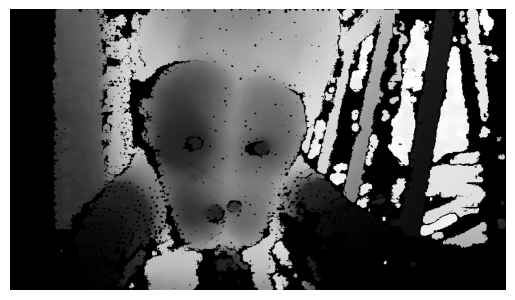

In [43]:
for cow in clus2:
    image_names = feature_df[feature_df.cow == cow]["filename"].values
    image_name = image_names[0]
    filepath = os.path.join(image_path, str(cow), f"{image_name}.tif")
    img = img = ski.io.imread(filepath)
    img = exposure.equalize_hist(img, nbins=256, mask=None)
    fig, ax = plt.subplots()
    ax.imshow(img, cmap = "gray")
    ax.axis('off')
    fig.show()
    fig.savefig(f"{cow}_clus2.png", bbox_inches='tight', pad_inches=0)

In [35]:
cluster_df[cluster_df.cow == 1291][["cow", "max_eu", "min_teat", "kickoff_any_perc"]]

,cow,max_eu,min_teat,kickoff_any_perc
78,1291,4.416843,18.644595,1.258581


736
981
1295


C:\Users\marie\AppData\Local\Temp\ipykernel_32684\276750126.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


1321


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\marie\\rep_codes\\udder_project\\udder_video\\depth_images\\1321\\1321_20231117_141734_frame_191.tif'

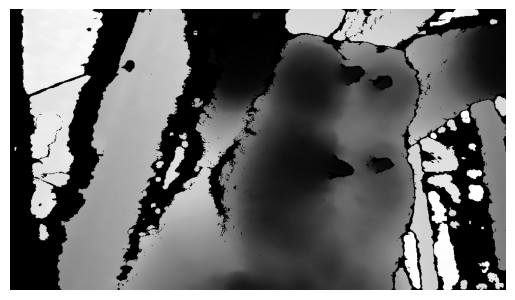

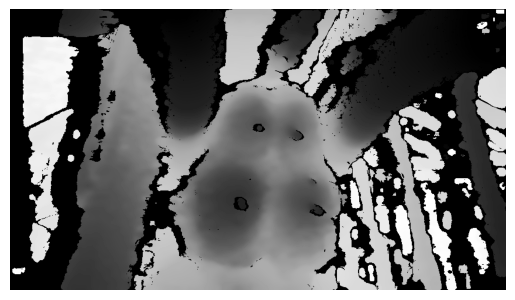

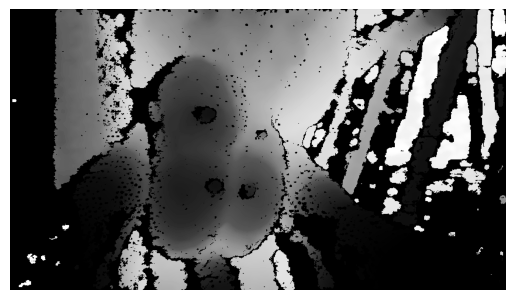

In [42]:
for cow in clus0:
    print(cow)
    image_names = feature_df[feature_df.cow == cow]["filename"].values
    image_name = image_names[0]
    filepath = os.path.join(image_path, str(cow), f"{image_name}.tif")
    img = img = ski.io.imread(filepath)
    img = exposure.equalize_hist(img, nbins=256, mask=None)
    fig, ax = plt.subplots()
    ax.imshow(img, cmap = "gray")
    ax.axis('off')
    fig.show()
    fig.savefig(f"{cow}_clus0.png", bbox_inches='tight', pad_inches=0)

In [32]:
cluster_df[cluster_df.min_teat > 45][["cow", "max_eu", "min_teat", "kickoff_any_perc"]]

,cow,max_eu,min_teat,kickoff_any_perc
3,736,5.309200,49.515135,1.747815
22,981,8.981211,45.345177,1.315789
80,1295,6.491649,45.138132,1.326260
86,1321,14.087270,45.104245,1.376147


929


C:\Users\marie\AppData\Local\Temp\ipykernel_32684\1645860931.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


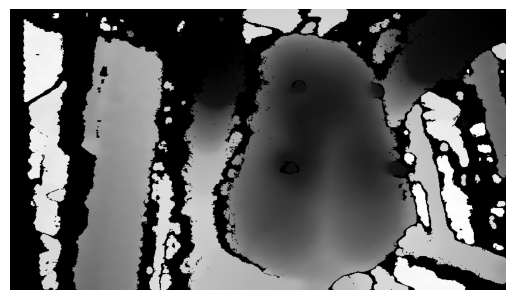

In [41]:
for cow in clus1:
    print(cow)
    image_names = feature_df[feature_df.cow == cow]["filename"].values
    image_name = image_names[-1]
    filepath = os.path.join(image_path, str(cow), f"{image_name}.tif")
    img = img = ski.io.imread(filepath)
    img = exposure.equalize_hist(img, nbins=256, mask=None)
    fig, ax = plt.subplots()
    ax.imshow(img, cmap = "gray")
    ax.axis('off')
    fig.show()
    fig.savefig(f"{cow}_clus1.png", bbox_inches='tight', pad_inches=0)

In [37]:
# highest ko perc cow
cluster_df[cluster_df.cow == 929][["cow", "max_eu", "min_teat", "kickoff_any_perc"]]

,cow,max_eu,min_teat,kickoff_any_perc
15,929,20.940308,24.849285,8.333333


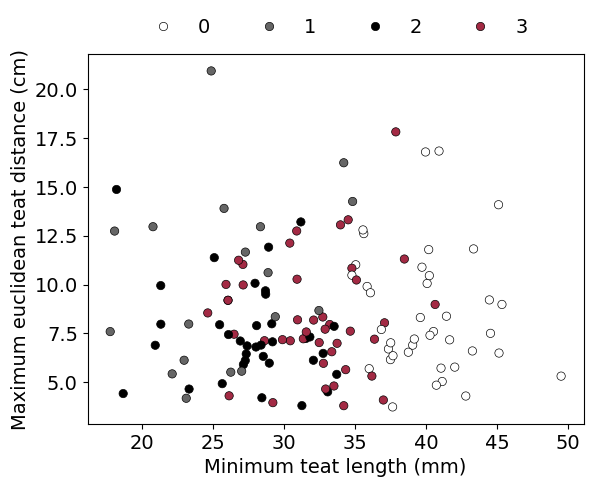

In [39]:
plt.rcParams.update({'font.size': 14})
cluster_df["cluster"] = cluster_df["cluster"].astype('category')
my_colors = ["white" , "#666666",  'black',  '#A32A44']
sns.set_palette( my_colors ) 
ax = sns.scatterplot(x=cluster_df.min_teat , y= cluster_df.max_eu, hue = cluster_df.cluster, edgecolor='black')
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
)
plt.ylabel("Maximum euclidean teat distance (cm)")
plt.xlabel("Minimum teat length (mm)")
plt.savefig(f"clusters.png", bbox_inches='tight', pad_inches=0.3)

In [36]:
# highest ko perc cow
cluster_df[cluster_df.cow == 1501][["cow", "max_eu", "min_teat", "kickoff_any_perc"]]

,cow,max_eu,min_teat,kickoff_any_perc
136,1501,10.233381,35.086378,62.790698


In [50]:
image_path = r"C:\Users\marie\rep_codes\udder_project\udder_processing\depth_images"
max_ko_perc = np.nanmax(cluster_df.kickoff_any_perc)
cow = cluster_df[cluster_df.kickoff_any_perc == max_ko_perc]["cow"].values[0]
image_names = feature_df[feature_df.cow == cow]["filename"].values
image_name = image_names[2]
filepath = os.path.join(image_path, str(cow), f"{image_name}.tif")
img = img = ski.io.imread(filepath)
img = exposure.equalize_hist(img, nbins=256, mask=None)
fig, ax = plt.subplots()
ax.imshow(img, cmap = "gray")
ax.axis('off')
fig.show()
fig.savefig(f"{cow}_max_ko.png", bbox_inches='tight', pad_inches=0)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\marie\\rep_codes\\udder_project\\udder_processing\\depth_images\\1501\\1501_20231117_173317_frame_160.tif'

In [20]:

cow

array([1501], dtype=int64)